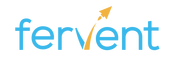
# Reducing Risk by Diversification
In this walkthrough, you'll learn how (and why) risk reduces by diversification.

In [1]:
# Import package dependencies
import pandas as pd  # for data management and analysis
import numpy as np  # for numerical computations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for making charts look good
sns.set()  # implementing the seaborn plotting templates / themes

<div class="alert alert-block alert-info">
<b>Confused by the code below?</b>  

Go back to the lecture on Estimating Portfolio Risk - Multiple Assets (Applied) to understand the code in `In[2]` and `In[3]` before moving on any further.
</div>


In [2]:
df = pd.read_csv('../data/10stocks_price.csv')  # stock price data

# Convert dates to timestamps and set date column as the index
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'])
df.set_index('date_gsheets', inplace=True)

# Calculate returns for each stock
returns_df = df.pct_change(1)

In [3]:
# Estimating the risk of a 10 asset portfolio
num_stocks = 10
weights = [1 / num_stocks] * num_stocks  # vector (list) of weights
vcv_matrix = returns_df.cov()  # variance covariance matrix

# Calculate variance and standard deviation of the 10 asset portfolio
var_portfolio = np.dot(np.transpose(weights), np.dot(vcv_matrix, weights))
sd_portfolio = np.sqrt(var_portfolio)
sd_portfolio_annual = sd_portfolio * np.sqrt(250)

# Estimate individual stock risks for comparison
individual_risks = np.std(returns_df) * np.sqrt(250)

In [4]:
returns_df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
date_gsheets,,,,,,,,,,
2012-01-03 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04 16:00:00,0.005277,-0.006273,0.113372,-0.011329,0.014096,-0.004079,-0.013088,-0.010277,0.010893,-0.013177
2012-01-05 16:00:00,0.011175,-0.004591,-0.013925,0.001693,0.016731,-0.004743,-0.006886,-0.004857,-0.000539,-0.021292
2012-01-06 16:00:00,0.010382,-0.006342,0.088261,-0.007019,0.010380,-0.011481,-0.015665,-0.007068,0.005391,-0.007743
2012-01-09 16:00:00,-0.001492,0.000000,0.137875,-0.001309,-0.004009,-0.005204,0.001044,0.003051,0.011260,0.012635


In [7]:
# Extract a list of all the tickers in the dataframe
tickers = list(returns_df.columns)

In [10]:
# Exploring results using index slicing
tickers[0:2]

['AAPL', 'KO']

In [11]:
# Create 10 portfolios with each ensuing portfolio comprising of ONE additional stock.
portfolios = []

for i in range(1, len(tickers) + 1):
    portfolios.append(tickers[0:i])

In [12]:
portfolios

[['AAPL'],
 ['AAPL', 'KO'],
 ['AAPL', 'KO', 'NFLX'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT', 'GE'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT', 'GE', 'TSLA']]

<div class="alert alert-block alert-info">
<b>Confused by the code below?</b>  

Go back to the lecture on Estimating Portfolio Risk - Multiple Assets (Applied) to understand the code in `In[13]` before moving on any further.
</div>


In [13]:
# Calculate the risk of each portfolio
portfolio_risks = []

for port in portfolios:
    df = returns_df[port]
    
    num_stocks = len(df.columns)
    weights = [1 / num_stocks] * num_stocks
    vcv_p = df.cov()
    
    var_p = np.dot(np.transpose(weights), np.dot(vcv_p, weights))
    sd_p = np.sqrt(var_p)
    sd_p_annual = sd_p * np.sqrt(250)
    
    portfolio_risks.append(sd_p_annual)

In [15]:
portfolio_risks

[0.24808505375568857,
 0.15361677406524385,
 0.2114565541739027,
 0.17491660730394207,
 0.1575915986342165,
 0.14571266561387214,
 0.13422929292622476,
 0.12628134430343535,
 0.12416648815658812,
 0.13539455221149152]

In [16]:
# Create a dataframe of all the portfolio risks
risks_df = pd.DataFrame(portfolio_risks)

In [18]:
risks_df.rename(columns={risks_df.columns[0] : 'total_risk'}, inplace=True)

In [19]:
risks_df

,total_risk
0,0.248085
1,0.153617
2,0.211457
3,0.174917
4,0.157592
5,0.145713
6,0.134229
7,0.126281
8,0.124166
9,0.135395


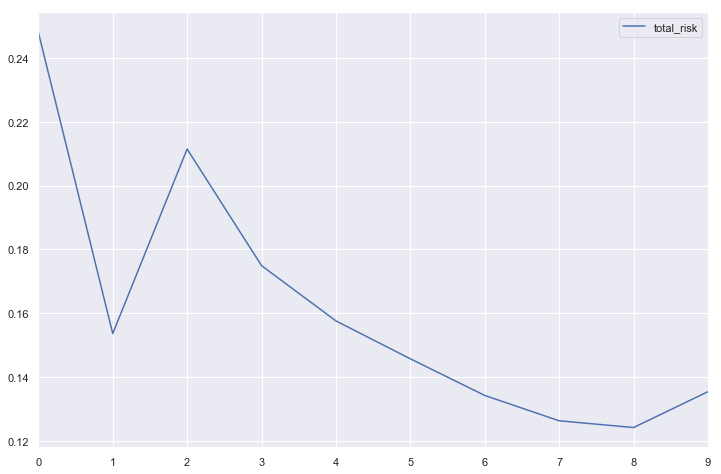

In [20]:
# Plot the portfolio risk of each of the 10 portfolios
risks_df.plot(figsize=(12, 8))

In [21]:
# Compare the risk of portfolios with the risk of individual securities
np.std(returns_df) * np.sqrt(250)

AAPL     0.248003
KO       0.137257
NFLX     0.515302
BRK.B    0.141030
DIS      0.181313
IBM      0.181705
VZ       0.160220
WMT      0.169281
GE       0.184478
TSLA     0.482230
dtype: float64